In [129]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from temgym_core.components import Lens, Detector, Plane, ElectromagneticLens
from temgym_core.ray import Ray
from temgym_core.source import make_waist_divergence_rays
from temgym_core.gaussian import make_gaussian
from temgym_core.run import run_to_end
from temgym_core.evaluate import evaluate_gaussians_for
from temgym_core.plotting import plot_model, legacy_beam_plot_params
from temgym_core.constants import compute_rotation_angle_Gc_from_NI_focal_length, compute_Rc_from_voltage
from temgym_core.utils import custom_jacobian_matrix
%matplotlib widget

import jax
jax.config.update("jax_enable_x64", True)

In [130]:
voltage = 200e3
rotation_constant = 0.0 #compute_Rc_from_voltage(voltage) 
C_mini_rotation_angle, C_mini_Gc = compute_rotation_angle_Gc_from_NI_focal_length(focal_length=0.005, NI=2000, Rc=rotation_constant)
Obj_prefield_rotation_angle, Obj_prefield_Gc = compute_rotation_angle_Gc_from_NI_focal_length(focal_length=0.005, NI=3000, Rc=rotation_constant)
print(f"C_mini_rotation_angle = {C_mini_rotation_angle:.1f} rad, C_mini_Gc= {C_mini_Gc:.2e} [1/(AT²·m)]")
print(f"Obj_prefield_rotation_angle = {Obj_prefield_rotation_angle:.1f} rad, Obj_prefield_Gc= {Obj_prefield_Gc:.2e} [1/(AT²·m)]")

C_mini_rotation_angle = 0.0 rad, C_mini_Gc= 5.00e-05 [1/(AT²·m)]
Obj_prefield_rotation_angle = 0.0 rad, Obj_prefield_Gc= 2.22e-05 [1/(AT²·m)]


In [131]:
drive = np.load(Path("examples/microscope_models/data/microscope_design_curves.npz"))

spot_control_values = drive["spot_control_values"]
mag_control_values = drive["mag_control_values"]

spot_currents_table = drive["spot_currents_a"]            # [CL1, CL3]
spot_focals_table = drive["spot_lens_focals_m"]           # [CL1, CL3]
mag_currents_il_table = drive["mag_currents_a_il"]        # [IL1, IL2, IL3]
mag_focals_table = drive["mag_lens_focals_m"]             # [IL1, IL2, IL3]
mag_currents_comp_table = drive["mag_currents_a_comp"]    # [Obj_post, PL1]

spot_choice = float(spot_control_values[0])
magnification_choice = float(mag_control_values[0])

def interpolate_table(control_values, table, control_value):
    return np.array(
        [
            np.interp(control_value, control_values, table[:, i])
            for i in range(table.shape[1])
        ],
        dtype=float,
    )

spot_currents = interpolate_table(spot_control_values, spot_currents_table, spot_choice)
spot_focals = interpolate_table(spot_control_values, spot_focals_table, spot_choice)
mag_currents_il = interpolate_table(mag_control_values, mag_currents_il_table, magnification_choice)
mag_focals = interpolate_table(mag_control_values, mag_focals_table, magnification_choice)
mag_currents_comp = interpolate_table(mag_control_values, mag_currents_comp_table, magnification_choice)

print("Available spot controls:", spot_control_values)
print("Available magnification controls:", mag_control_values)
print(f"Selected spot control = {spot_choice}")
print(f"Selected magnification control = {magnification_choice}")
print(f"Currents [CL1, CL3] [A] = {spot_currents}")
print(f"Focals [CL1, CL3] [m] = {spot_focals}")
print(f"Currents [Obj_post, PL1] [A] = {mag_currents_comp}")
print(f"Currents [IL1, IL2, IL3] [A] = {mag_currents_il}")
print(f"Focals [IL1, IL2, IL3] [m] = {mag_focals}")

Available spot controls: [1. 2. 3. 4. 5. 6. 7. 8.]
Available magnification controls: [ 30000.  50000. 100000. 300000. 600000.]
Selected spot control = 1.0
Selected magnification control = 30000.0
Currents [CL1, CL3] [A] = [0.77391664 1.32978141]
Focals [CL1, CL3] [m] = [0.02318885 0.01090874]
Currents [Obj_post, PL1] [A] = [-2.94 -1.89]
Currents [IL1, IL2, IL3] [A] = [2.01826124 1.11525317 2.15735497]
Focals [IL1, IL2, IL3] [m] = [0.00340967 0.02512483 0.00671439]


In [132]:
CL1_current, CL3_current = spot_currents
Obj_post_current, PL1_current = mag_currents_comp
IL1_current, IL2_current, IL3_current = mag_currents_il
f_cl1_design, f_cl3_design = spot_focals
f_il1_design, f_il2_design, f_il3_design = mag_focals

M_obj = 80.0
M_proj = 100.0
invert_image = True
M_il_target = float(magnification_choice) / (M_obj * M_proj)
A_il_target = -M_il_target if invert_image else M_il_target

geometry_cond = {
    "d_S_C1": 0.2,
    "d_C1_C3": 0.04,
    "d_C3_A": 10.0e-3,
    "d_A_Cmini": 50.0e-3,
    "d_Cmini_OPL": 20.0e-3,
    "f_Cmini": 5.0e-3,
    "f_OPL": 5.0e-3,
}

geometry_mag = {
    "d_obj_to_il1": 10e-3,
    "d_il1_to_il2": 52e-3,
    "d_il2_to_il3": 62e-3,
    "d_il3_to_image": 48.75e-3,
}
geometry_proj = {
    "d_il3_to_pl1": 52e-3,
    "d_pre_pl1_image_to_pl1": 3.25e-3,
    "d_pl1_to_detector": 0.325,
}
if not np.isclose(
    geometry_mag["d_il3_to_image"] + geometry_proj["d_pre_pl1_image_to_pl1"],
    geometry_proj["d_il3_to_pl1"],
    atol=1e-12,
):
    raise ValueError("Inconsistent projector geometry: d_il3_to_image + d_pre_pl1_image_to_pl1 must equal d_il3_to_pl1.")

z_source = 0.0
z_cl1 = z_source + geometry_cond["d_S_C1"]
z_cl3 = z_cl1 + geometry_cond["d_C1_C3"]
z_aperture = z_cl3 + geometry_cond["d_C3_A"]
z_cmini = z_aperture + geometry_cond["d_A_Cmini"]
z_obj_prefield = z_cmini + geometry_cond["d_Cmini_OPL"]
z_sample = z_obj_prefield + geometry_cond["f_OPL"]

z_obj_post = z_sample + 2.3e-3
z_sa_aperture = z_obj_post + 2.3e-3 * 80
z_il1 = z_obj_post + geometry_mag["d_obj_to_il1"]
z_il2 = z_il1 + geometry_mag["d_il1_to_il2"]
z_il3 = z_il2 + geometry_mag["d_il2_to_il3"]
z_pre_pl1_image = z_il3 + geometry_mag["d_il3_to_image"]
z_pl1 = z_pre_pl1_image + geometry_proj["d_pre_pl1_image_to_pl1"]
z_detector = z_pl1 + geometry_proj["d_pl1_to_detector"]

CL1_em = ElectromagneticLens(z=z_cl1, turns=3000, current=float(CL1_current), Gc=8e-6, Rc=rotation_constant)
CL3_em = ElectromagneticLens(z=z_cl3, turns=3600, current=float(CL3_current), Gc=4e-6, Rc=rotation_constant)
C_mini_em = ElectromagneticLens(z=z_cmini, turns=2000, current=1.0, Gc=C_mini_Gc, Rc=rotation_constant)
Obj_prefield_em = ElectromagneticLens(z=z_obj_prefield, turns=3000, current=1.0, Gc=Obj_prefield_Gc, Rc=rotation_constant)
Sample_plane = Plane(z=z_sample)
Obj_post_em = ElectromagneticLens(z=z_obj_post, turns=3000, current=float(Obj_post_current), Gc=8e-6, Rc=rotation_constant)
IL1_em = ElectromagneticLens(z=z_il1, turns=3000, current=float(IL1_current), Gc=8e-6, Rc=rotation_constant)
IL2_em = ElectromagneticLens(z=z_il2, turns=2000, current=float(IL2_current), Gc=8e-6, Rc=rotation_constant)
IL3_em = ElectromagneticLens(z=z_il3, turns=2000, current=float(IL3_current), Gc=8e-6, Rc=rotation_constant)
PL1_em = ElectromagneticLens(z=z_pl1, turns=2000, current=float(PL1_current), Gc=8e-6, Rc=rotation_constant)
sample_detector = Detector(z=z_detector, pixel_size=(5e-9, 5e-9), shape=(256, 256))

def em_to_lens(em):
    return Lens(z=float(em.z), focal_length=float(em.focal_length))

CL1 = em_to_lens(CL1_em)
CL3 = em_to_lens(CL3_em)
C_mini = em_to_lens(C_mini_em)
Obj_prefield = em_to_lens(Obj_prefield_em)
Obj_post = em_to_lens(Obj_post_em)
IL1_lens = em_to_lens(IL1_em)
IL2_lens = em_to_lens(IL2_em)
IL3_lens = em_to_lens(IL3_em)
PL1_lens = em_to_lens(PL1_em)

def assert_close(name, value, target, atol=1e-12, rtol=1e-6):
    if not np.isclose(value, target, atol=atol, rtol=rtol):
        raise ValueError(f"{name} mismatch: got {value:.6e}, expected {target:.6e}")

assert_close("d_S_C1", z_cl1 - z_source, geometry_cond["d_S_C1"])
assert_close("d_C1_C3", z_cl3 - z_cl1, geometry_cond["d_C1_C3"])
assert_close("d_C3_A", z_aperture - z_cl3, geometry_cond["d_C3_A"])
assert_close("d_A_Cmini", z_cmini - z_aperture, geometry_cond["d_A_Cmini"])
assert_close("d_Cmini_OPL", z_obj_prefield - z_cmini, geometry_cond["d_Cmini_OPL"])
assert_close("d_sample_from_OPL", z_sample - z_obj_prefield, geometry_cond["f_OPL"])
assert_close("d_obj_to_il1", z_il1 - z_obj_post, geometry_mag["d_obj_to_il1"])
assert_close("d_il1_to_il2", z_il2 - z_il1, geometry_mag["d_il1_to_il2"])
assert_close("d_il2_to_il3", z_il3 - z_il2, geometry_mag["d_il2_to_il3"])
assert_close("d_il3_to_pre_pl1_image", z_pre_pl1_image - z_il3, geometry_mag["d_il3_to_image"])
assert_close("d_il3_to_pl1", z_pl1 - z_il3, geometry_proj["d_il3_to_pl1"])
assert_close("d_pre_pl1_image_to_pl1", z_pl1 - z_pre_pl1_image, geometry_proj["d_pre_pl1_image_to_pl1"])
assert_close("d_pl1_to_detector", z_detector - z_pl1, geometry_proj["d_pl1_to_detector"])

assert_close("f_CL1(current) vs design", CL1.focal_length, f_cl1_design, atol=1e-12, rtol=1e-3)
assert_close("f_CL3(current) vs design", CL3.focal_length, f_cl3_design, atol=1e-12, rtol=1e-3)
assert_close("f_Cmini", C_mini.focal_length, geometry_cond["f_Cmini"], atol=1e-12, rtol=1e-6)
assert_close("f_Obj_prefield", Obj_prefield.focal_length, geometry_cond["f_OPL"], atol=1e-12, rtol=1e-6)
assert_close("f_IL1(current) vs design", IL1_lens.focal_length, f_il1_design, atol=1e-12, rtol=1e-3)
assert_close("f_IL2(current) vs design", IL2_lens.focal_length, f_il2_design, atol=1e-12, rtol=1e-3)
assert_close("f_IL3(current) vs design", IL3_lens.focal_length, f_il3_design, atol=1e-12, rtol=1e-3)

def focal_from_current(current, turns, gc):
    ni = turns * current
    denom = gc * ni**2
    return np.inf if np.isclose(denom, 0.0) else (1.0 / denom)

f_pl1_target = 1.0 / (
    (1.0 / geometry_proj["d_pre_pl1_image_to_pl1"])
    + (1.0 / geometry_proj["d_pl1_to_detector"])
)
f_obj_post_design = focal_from_current(Obj_post_current, 3000.0, 8e-6)
f_pl1_design = focal_from_current(PL1_current, 2000.0, 8e-6)
assert_close("f_PL1(target from projector geometry)", PL1_lens.focal_length, f_pl1_target, atol=1e-12, rtol=1e-3)
assert_close("f_Obj_post(from design current)", Obj_post.focal_length, f_obj_post_design, atol=1e-12, rtol=1e-12)
assert_close("f_PL1(from design current)", PL1_lens.focal_length, f_pl1_design, atol=1e-12, rtol=1e-12)
ni_net = IL1_em.excitation + IL2_em.excitation + IL3_em.excitation + Obj_post_em.excitation + PL1_em.excitation
assert_close("net_NI_rotation_cancel", ni_net, 0.0, atol=1e-9, rtol=0.0)

print("Condenser geometry reconstructed from design model:")
print(f"  z_source={z_source:.6f}, z_cl1={z_cl1:.6f}, z_cl3={z_cl3:.6f}, z_aperture={z_aperture:.6f}")
print(f"  z_cmini={z_cmini:.6f}, z_obj_prefield={z_obj_prefield:.6f}, z_sample={z_sample:.6f}")
print("Projector geometry checks:")
print(f"  d_obj_to_il1={(z_il1 - z_obj_post)*1e3:.3f} mm, d_il1_to_il2={(z_il2 - z_il1)*1e3:.3f} mm")
print(f"  d_il2_to_il3={(z_il3 - z_il2)*1e3:.3f} mm, d_il3_to_pre_pl1_image={(z_pre_pl1_image - z_il3)*1e3:.3f} mm")
print(f"  d_pre_pl1_image_to_pl1={(z_pl1 - z_pre_pl1_image)*1e3:.3f} mm, d_pl1_to_detector={(z_detector - z_pl1)*1e3:.3f} mm")
print("Condenser focal checks:")
print(f"  CL1: design={f_cl1_design*1e3:.4f} mm, from current={CL1.focal_length*1e3:.4f} mm")
print(f"  CL3: design={f_cl3_design*1e3:.4f} mm, from current={CL3.focal_length*1e3:.4f} mm")
print(f"  Cmini={C_mini.focal_length*1e3:.4f} mm, Obj_prefield={Obj_prefield.focal_length*1e3:.4f} mm")
print("Projector focal checks:")
print(f"  IL1: design={f_il1_design*1e3:.4f} mm, from current={IL1_lens.focal_length*1e3:.4f} mm")
print(f"  IL2: design={f_il2_design*1e3:.4f} mm, from current={IL2_lens.focal_length*1e3:.4f} mm")
print(f"  IL3: design={f_il3_design*1e3:.4f} mm, from current={IL3_lens.focal_length*1e3:.4f} mm")
print(f"  PL1 target from projector geometry={f_pl1_target*1e3:.4f} mm")
print(f"  Obj_post(from design current)={Obj_post.focal_length*1e3:.4f} mm")
print(f"  PL1(from design current)={PL1_lens.focal_length*1e3:.4f} mm")
print(f"  Net NI (IL + Obj_post + PL1)={ni_net:.6e} AT")

components_to_sample = [CL1, CL3, C_mini, Obj_prefield, Sample_plane]
components_to_detector = [
    CL1, CL3, C_mini, Obj_prefield, Sample_plane, Obj_post, IL1_lens, IL2_lens, IL3_lens, PL1_lens, sample_detector 
]

components_for_plot = [
    CL1_em,
    CL3_em,
    C_mini_em,
    Obj_prefield_em,
    Sample_plane,
    Obj_post_em,
    IL1_em,
    IL2_em,
    IL3_em,
    PL1_em,
    sample_detector,
]

component_name_by_z = [
    (z_cl1, "CL1"),
    (z_cl3, "CL3"),
    (z_cmini, "C_mini"),
    (z_obj_prefield, "Obj_prefield"),
    (z_sample, "Sample"),
    (z_obj_post, "Obj_post"),
    (z_il1, "IL1"),
    (z_il2, "IL2"),
    (z_il3, "IL3"),
    (z_pl1, "PL1"),
    (z_detector, "Detector"),
]

source_waist_m = 10e-9
beam_in = make_gaussian(
    x=0.0, y=0.0, dx=0.0, dy=0.0, z=z_source,
    voltage=voltage,
    waist_x=source_waist_m,
    waist_y=source_waist_m,
    amp=1.0,
    phase=0.0,
    rcurv_x=np.inf,
    rcurv_y=np.inf,
    wavelength_unit="m",
)

beam_at_sample = run_to_end(beam_in, components_to_sample)



ValueError: f_PL1(target from projector geometry) mismatch: got 8.748355e-03, expected 3.217822e-03

In [ ]:
beam_at_detector = run_to_end(beam_in, components_to_detector)

def beam_radius_from_qinv(beam):
    q = np.asarray(beam.Q_inv)
    lam = float(np.asarray(beam.wavelength))
    im_x = float(np.abs(np.imag(q[0, 0])))
    im_y = float(np.abs(np.imag(q[1, 1])))
    wx = np.sqrt(lam / (np.pi * max(im_x, 1e-30)))
    wy = np.sqrt(lam / (np.pi * max(im_y, 1e-30)))
    return max(wx, wy)


field_sample = np.asarray(evaluate_gaussians_for(beam_at_sample, sample_detector))

intensity_sample = np.abs(field_sample) ** 2

sample_x, sample_y = sample_detector.coords_1d

sample_extent_nm = (float(np.min(sample_x * 1e9)), float(np.max(sample_x * 1e9)), float(np.min(sample_y * 1e9)), float(np.max(sample_y * 1e9)))

fig, axs = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

im0 = axs[0].imshow(
    intensity_sample / np.maximum(np.max(intensity_sample), 1e-30),
    origin="lower",
    extent=sample_extent_nm,
    cmap="inferno",
)
axs[0].set_title("Gaussian intensity at sample")
axs[0].set_xlabel("x [nm]")
axs[0].set_ylabel("y [nm]")
plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

plt.show()

AttributeError: 'ElectromagneticLens' object has no attribute 'complex_action'

Imaging diagnostics:
  CL1: s=200.000 mm, f=23.189 mm, s'=26.230 mm, z_img=0.226230 m
  CL3: s=13.770 mm, f=10.909 mm, s'=52.500 mm, z_img=0.292500 m
  Between CL1 and CL3? True
  C_mini object plane z=0.292500 m


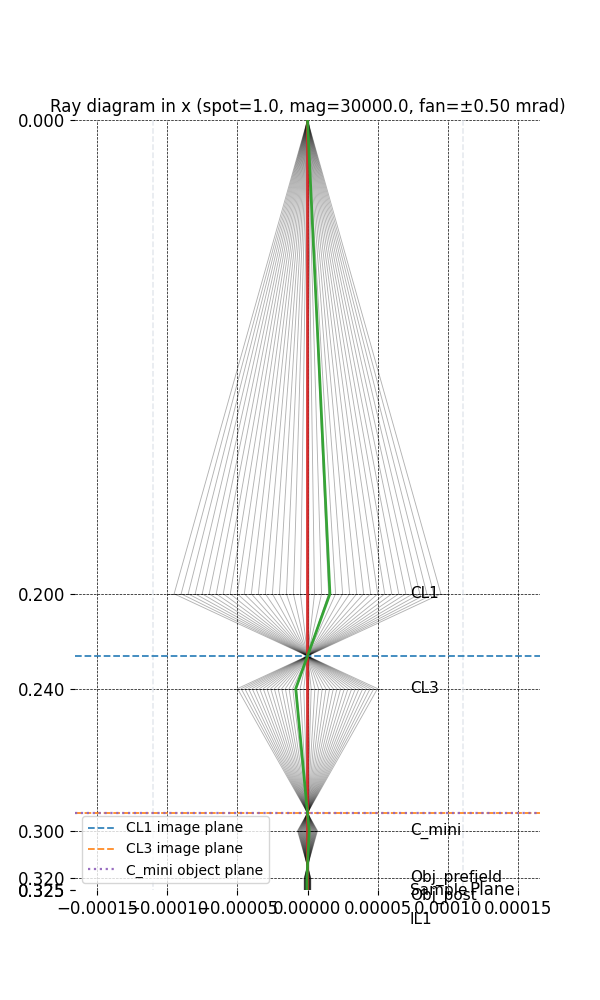

In [ ]:
# --- Ray diagram and CL1/CL3 imaging diagnostics ---
s1 = z_cl1 - z_source
s1p = 1.0 / ((1.0 / CL1.focal_length) - (1.0 / s1))
z_img_after_cl1 = z_cl1 + s1p
s3 = z_cl3 - z_img_after_cl1
s3p = 1.0 / ((1.0 / CL3.focal_length) - (1.0 / s3))
z_img_after_cl3 = z_cl3 + s3p

d_img_fopl = geometry_cond["d_Cmini_OPL"] - geometry_cond["f_OPL"]
d_obj_cmini = 1.0 / ((1.0 / C_mini.focal_length) - (1.0 / d_img_fopl))
z_obj_cmini = z_cmini - d_obj_cmini

print("Imaging diagnostics:")
print(f"  CL1: s={s1*1e3:.3f} mm, f={CL1.focal_length*1e3:.3f} mm, s'={s1p*1e3:.3f} mm, z_img={z_img_after_cl1:.6f} m")
print(f"  CL3: s={s3*1e3:.3f} mm, f={CL3.focal_length*1e3:.3f} mm, s'={s3p*1e3:.3f} mm, z_img={z_img_after_cl3:.6f} m")
print(f"  Between CL1 and CL3? {z_cl1 < z_img_after_cl1 < z_cl3}")
print(f"  C_mini object plane z={z_obj_cmini:.6f} m")

source_basis = make_waist_divergence_rays(
    waist=source_waist_m,
    voltage=voltage,
    z=z_source,
    x0=0.0,
    y0=0.0,
)

theta0_from_waist = float(np.max(np.abs(np.asarray(source_basis.dx))))
fan_half_angle_mrad = 0.5
theta0 = max(theta0_from_waist, fan_half_angle_mrad * 1e-3)

fan_num_rays = 41
dx_fan = np.linspace(-theta0, theta0, fan_num_rays)

fan_rays = Ray(
    x=np.zeros_like(dx_fan),
    y=np.zeros_like(dx_fan),
    dx=dx_fan,
    dy=np.zeros_like(dx_fan),
    z=np.full_like(dx_fan, z_source),
    pathlength=np.zeros_like(dx_fan),
)

fig, ax = plot_model(
    components_for_plot,
    rays=fan_rays,
    solution_rays=source_basis,
    include_input_rays=True,
    plot_params=legacy_beam_plot_params(),
    band_mode="lines",
    ray_coordinate='x',
    r_side_by_sign=False,
)

for txt in list(ax.texts):
    if txt.get_text() in ("ElectromagneticLens", "Detector"):
        txt.set_visible(False)

x_left, x_right = ax.get_xlim()
x_label = x_right - 0.28 * (x_right - x_left)
for z_val, name in component_name_by_z:
    ax.text(x_label, z_val, name, va="center", ha="left", fontsize=11, color="black")

ax.axhline(z_img_after_cl1, color="tab:blue", linestyle="--", linewidth=1.3, alpha=0.9, label="CL1 image plane")
ax.axhline(z_img_after_cl3, color="tab:orange", linestyle="--", linewidth=1.3, alpha=0.9, label="CL3 image plane")
ax.axhline(z_obj_cmini, color="tab:purple", linestyle=":", linewidth=1.6, alpha=0.95, label="C_mini object plane")
ax.legend(loc="lower left")

ax.set_title(
    f"Ray diagram in x (spot={spot_choice}, mag={magnification_choice}, fan=±{theta0*1e3:.2f} mrad)"
)
plt.show()